## Sección 0: Configuración del problema de clasificación

**De la detección de anomalías a la clasificación supervisada.** El dataset UCI Hydraulic System (ID 447) tiene **cuatro variables objetivo independientes**, cada una con niveles discretos que representan distintos grados de degradación de un componente físico: `cooler_condition` (3 niveles), `valve_condition` (4 niveles), `pump_leakage` (3 niveles) y `accumulator_pressure` (4 niveles). Esto constituye un problema de **clasificación multi-clase multi-salida**: las cuatro salidas son estadísticamente independientes por construcción del diseño factorial (Sección 2 del EDA — 144 combinaciones cruzadas deliberadamente), pero no son necesariamente independientes en términos de la covarianza de los sensores que las observan, ya que los cuatro componentes comparten el mismo circuito hidráulico físico.

**Por qué clasificación supervisada y no detección de anomalías.** La Fase 3 demostró, con evidencia numérica y no solo argumentación teórica, que la detección no supervisada fracasa en este dataset concreto: el diseño factorial equilibrado hace que el estado "los cuatro componentes en su óptimo simultáneamente" sea la combinación más rara del diseño (1 de 144 celdas, 0.69% de los ciclos) — justo lo opuesto de la premisa bajo la que operan Mahalanobis, Isolation Forest o un autoencoder, que asumen que lo normal es lo mayoritario y lo raro es lo patológico. Aquí ocurre lo contrario, y por eso Isolation Forest terminó con AUC-ROC=0.27 (peor que el azar) en la Sección 3 de la Fase 3. La clasificación supervisada no depende de esa premisa: cada ciclo tiene una etiqueta conocida y verificada, y el objetivo pasa a ser aprender la frontera de decisión de cada componente directamente a partir de esas etiquetas, sin necesidad de inferir "normalidad" a partir de la densidad del espacio de features.

**Estrategia de modelado: cuatro clasificadores independientes, no un modelo multi-salida conjunto.** Se entrenará un clasificador separado por cada uno de los cuatro targets, en lugar de un único modelo multi-salida. Esto permite optimizar hiperparámetros, umbrales de decisión y métricas de forma independiente para cada objetivo — cada componente puede requerir un modelo distinto según su dificultad relativa (número de clases, balance, señal disponible en los features). Esta decisión respeta también la naturaleza física del sistema: el estado del refrigerador, la válvula, la bomba y el acumulador son **mecanismos de degradación distintos**, con rutas causales diferentes en el espacio de sensores (ya documentado en la Fase 2: cada target tiene su propio conjunto de features dominantes según η²), y no hay ninguna razón a priori para forzarlos a compartir una única arquitectura de modelo.

### Imports y configuración

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
# ── Carga de los 4 Parquet exportados por la Fase 2 ──
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

TARGETS = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]

print("\nValores únicos por target (y_train):")
for target in TARGETS:
    print(f"{target}: {sorted(y_train[target].unique().tolist())}")


X_train: (1157, 73)
X_test:  (290, 73)
y_train: (1157, 4)
y_test:  (290, 4)

Valores únicos por target (y_train):
cooler_condition: [3, 20, 100]
valve_condition: [73, 80, 90, 100]
pump_leakage: [0, 1, 2]
accumulator_pressure: [90, 100, 115, 130]


In [3]:
# ── Distribución de clases por target, y baseline dummy (clase mayoritaria) ──
dummy_baselines = {}

for target in TARGETS:
    counts = y_train[target].value_counts().sort_index()
    props = y_train[target].value_counts(normalize=True).sort_index()

    dist_table = pd.DataFrame({"conteo": counts, "proporción": props.round(4)})
    print(f"\n=== {target} ===")
    print(dist_table.to_string())

    dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train[target])
    acc_dummy = accuracy_score(y_train[target], dummy.predict(X_train))
    dummy_baselines[target] = acc_dummy
    print(f"Baseline dummy (clase mayoritaria) — accuracy: {acc_dummy:.4f}")

print("\n=== Resumen baselines dummy ===")
for target, acc in dummy_baselines.items():
    print(f"{target}: {acc:.4f}")



=== cooler_condition ===
                  conteo  proporción
cooler_condition                    
3                    382      0.3302
20                   384      0.3319
100                  391      0.3379
Baseline dummy (clase mayoritaria) — accuracy: 0.3379

=== valve_condition ===
                 conteo  proporción
valve_condition                    
73                  287      0.2481
80                  288      0.2489
90                  287      0.2481
100                 295      0.2550
Baseline dummy (clase mayoritaria) — accuracy: 0.2550

=== pump_leakage ===
              conteo  proporción
pump_leakage                    
0                391      0.3379
1                384      0.3319
2                382      0.3302
Baseline dummy (clase mayoritaria) — accuracy: 0.3379

=== accumulator_pressure ===
                      conteo  proporción
accumulator_pressure                    
90                       294      0.2541
100                      288      0.2489
115  

### Interpretación

**Los datos cargados coinciden exactamente con lo exportado por la Fase 2:** `X_train` (1157, 73), `X_test` (290, 73), `y_train` (1157, 4), `y_test` (290, 4) — el mismo split 80/20 y las mismas 73 features usadas en las Fases 2 y 3. Los niveles de cada target, ordenados ascendentemente, son: `cooler_condition`=[3, 20, 100] (3 niveles), `valve_condition`=[73, 80, 90, 100] (4 niveles), `pump_leakage`=[0, 1, 2] (3 niveles), `accumulator_pressure`=[90, 100, 115, 130] (4 niveles) — confirma la estructura descrita en la Decisión.

**Las cuatro distribuciones de clase están, en la práctica, muy cerca del reparto uniforme esperado por el diseño factorial.** La clase mayoritaria de cada target y su proporción: `cooler_condition`=100 (33.79%), `valve_condition`=100 (25.50%), `pump_leakage`=0 (33.79%), `accumulator_pressure`=90 (25.41%). El baseline dummy (accuracy de predecir siempre la clase mayoritaria) reproduce exactamente esas proporciones: 0.3379, 0.2550, 0.3379 y 0.2541 respectivamente.

**`cooler_condition` y `pump_leakage` son, con el mismo valor exacto (0.3379), los más fáciles de igualar con un clasificador trivial** — pero esto es aritmética de número de clases, no desequilibrio real: con 3 clases, el reparto uniforme sería 33.33%, y ambos targets quedan a solo 0.46 puntos porcentuales de esa referencia. `accumulator_pressure` presenta la **distribución más equilibrada de las cuatro**: su baseline (25.41%) es el más bajo de los cuatro y el más cercano al 25.00% uniforme que le correspondería con 4 clases (desviación de 0.41pp, frente a 0.50pp de `valve_condition`). En conjunto, ningún target muestra desbalance real — el diseño factorial de la Fase 2 garantizó reparto proporcional por celda, y eso se traduce directamente en un reparto casi uniforme por target marginal.

**El baseline dummy, sin embargo, no anticipa la dificultad real de clasificación — para eso hace falta mirar la señal disponible en los features, ya cuantificada en la Fase 2 vía η².** Consultando `eta2_features_vs_targets.csv`: `cooler_condition` tiene η² máximo de 0.9984 (`CE_mean_second_half`) y η² **medio** de 0.6426 a través de las 73 features — y es, además, el target con mayor η² en 71 de las 73 columnas. Es, con enorme margen, el que más señal redundante tiene disponible: prácticamente cualquier subconjunto razonable de features debería bastar para clasificarlo con precisión alta. `valve_condition` tiene un η² máximo casi tan alto (0.9767, vía `PS3_peak_s`, ya señalado en la introducción de la Fase 3) pero un η² **medio** mucho más bajo (0.0176) y domina como mejor target en solo 1 de las 73 features — su clasificación probablemente dependerá casi por completo de que el modelo aproveche bien esa única columna, a diferencia de `cooler_condition`, cuya señal está distribuida ampliamente. `pump_leakage` (η² máximo=0.1526, vía `EPS1_mean`) y `accumulator_pressure` (η² máximo=0.0874, vía `PS1_mean_first_half`) tienen la señal más débil de los cuatro, por un margen considerable — son, a priori, los candidatos más probables a un desempeño de clasificación notablemente inferior al de `cooler_condition` y `valve_condition`, no por desbalance de clases (ya descartado arriba) sino por escasez genuina de señal discriminativa en las 73 features disponibles. Esta expectativa —fácil: cooler ≈ valve; difícil: pump ≈ accumulator, con pump ligeramente favorecido por tener casi el doble de η² máximo que accumulator— es la hipótesis de partida que las secciones siguientes deben confirmar o refutar con resultados reales de clasificación, no solo con la señal marginal por feature.


## Sección 1: Modelos baseline por componente

**Por qué empezar con configuraciones por defecto.** Antes de introducir cualquier ajuste de hiperparámetros hace falta establecer un piso de rendimiento: hasta dónde llega un modelo razonable sin ningún esfuerzo de optimización. Se usan dos clasificadores con roles distintos y complementarios. **Random Forest** (100 árboles, `random_state=42`) es invariante a la escala y captura interacciones no lineales entre features — el candidato natural para targets cuya señal está distribuida ampliamente entre muchas columnas, como `cooler_condition` (η² medio=0.6426 en 71 de 73 features, Sección 0). **Regresión Logística multinomial** (`max_iter=1000`, `solver='lbfgs'`, `random_state=42`) supone relaciones lineales en el espacio log-odds y requiere features estandarizados — actúa aquí como detector de si la señal disponible es lo bastante limpia para separación lineal, algo que Random Forest, al ser no lineal, no puede diagnosticar por sí solo.

**Validación cruzada estratificada de 5 folds, exclusivamente sobre `X_train`/`y_train`.** Usar el conjunto de test en esta etapa introduciría sesgo de selección: cualquier decisión tomada mirando el test (qué modelo preferir, qué hiperparámetros ajustar) contaminaría la evaluación final. El test queda sellado para la Sección 3. Las métricas reportadas son **accuracy** y **F1-macro**. Como los cuatro targets tienen distribuciones casi uniformes (Sección 0: baselines dummy entre 25.41% y 33.79%, todos a menos de 0.5pp del reparto uniforme esperado por su número de clases), el accuracy no sufre aquí el sesgo optimista que tendría con clases desbalanceadas. Aun así, F1-macro sigue siendo más informativo: pondera cada clase por igual sin importar su frecuencia, lo que importa en un contexto de mantenimiento predictivo donde detectar cualquier nivel de degradación merece la misma atención, no solo el más frecuente.

**Escalado dentro del pliegue de validación cruzada, no antes.** Para Random Forest se usa `X_train` directamente, sin estandarizar — no lo necesita. Para Regresión Logística, `StandardScaler` se ajusta sobre cada fold de entrenamiento dentro de un `Pipeline` (`StandardScaler` → `LogisticRegression`), nunca sobre el fold de validación completo ni sobre `X_train` entero antes de particionar: hacerlo así filtraría información del fold de validación hacia el ajuste del escalador, inflando artificialmente el resultado — el mismo principio de disciplina train/test que ha regido las Fases 2 y 3.


In [4]:
from sklearn.pipeline import Pipeline

# ── Validación cruzada baseline: Random Forest vs Regresión Logística, por target ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for target in TARGETS:
    y = y_train[target]

    # Random Forest — sin escalar, invariante a la escala
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_acc = cross_val_score(rf, X_train, y, cv=cv, scoring="accuracy")
    rf_f1 = cross_val_score(rf, X_train, y, cv=cv, scoring="f1_macro")
    cv_results.append({
        "target": target,
        "model": "RandomForest",
        "cv_accuracy_mean": rf_acc.mean(),
        "cv_accuracy_std": rf_acc.std(),
        "cv_f1macro_mean": rf_f1.mean(),
        "cv_f1macro_std": rf_f1.std(),
    })

    # Regresión Logística — escalado dentro de cada fold vía Pipeline
    # multi_class='multinomial' está deprecado desde sklearn 1.5 (será el único comportamiento en 1.7);
    # se deja explícito por claridad aunque ya sea el default, sin efecto sobre el resultado.
    logreg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs", random_state=RANDOM_STATE)),
    ])
    lr_acc = cross_val_score(logreg_pipeline, X_train, y, cv=cv, scoring="accuracy")
    lr_f1 = cross_val_score(logreg_pipeline, X_train, y, cv=cv, scoring="f1_macro")
    cv_results.append({
        "target": target,
        "model": "LogisticRegression",
        "cv_accuracy_mean": lr_acc.mean(),
        "cv_accuracy_std": lr_acc.std(),
        "cv_f1macro_mean": lr_f1.mean(),
        "cv_f1macro_std": lr_f1.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
print("Resultados de validación cruzada (5-fold estratificado, sobre X_train/y_train):")
print(cv_results_df.round(2).to_string(index=False))

print("\nBaseline dummy de referencia (Sección 0):")
for target, acc in dummy_baselines.items():
    print(f"  {target}: {acc:.4f}")


Resultados de validación cruzada (5-fold estratificado, sobre X_train/y_train):
              target              model  cv_accuracy_mean  cv_accuracy_std  cv_f1macro_mean  cv_f1macro_std
    cooler_condition       RandomForest              1.00             0.00             1.00            0.00
    cooler_condition LogisticRegression              1.00             0.00             1.00            0.00
     valve_condition       RandomForest              0.99             0.00             0.99            0.00
     valve_condition LogisticRegression              1.00             0.00             1.00            0.00
        pump_leakage       RandomForest              0.99             0.01             0.99            0.01
        pump_leakage LogisticRegression              0.99             0.01             0.99            0.01
accumulator_pressure       RandomForest              0.98             0.01             0.98            0.01
accumulator_pressure LogisticRegression              0.8

### Interpretación

**Resultados por target (media ± std sobre 5 folds):**

- `cooler_condition`: Random Forest accuracy=1.0000±0.0000, F1-macro=1.0000±0.0000; Regresión Logística accuracy=1.0000±0.0000, F1-macro=1.0000±0.0000 — **empate perfecto**, ambos modelos clasifican sin un solo error en los 5 folds.
- `valve_condition`: Random Forest accuracy=0.9922±0.0032, F1-macro=0.9922±0.0033; Regresión Logística accuracy=0.9983±0.0035, F1-macro=0.9983±0.0035 — **Regresión Logística supera a Random Forest por 0.61pp** en F1-macro, el único target donde el modelo lineal gana.
- `pump_leakage`: Random Forest accuracy=0.9948±0.0050, F1-macro=0.9948±0.0050; Regresión Logística accuracy=0.9905±0.0088, F1-macro=0.9905±0.0088 — Random Forest supera por 0.43pp, diferencia pequeña.
- `accumulator_pressure`: Random Forest accuracy=0.9844±0.0075, F1-macro=0.9845±0.0075; Regresión Logística accuracy=0.8228±0.0283, F1-macro=0.8207±0.0296 — **Random Forest supera a Regresión Logística por 16.38pp** en F1-macro, con enorme margen — la única brecha grande entre los dos modelos en las cuatro comparaciones.

**Mejora sobre el baseline dummy (mejor modelo de cada target vs. Sección 0):** `cooler_condition` +66.21pp (33.79%→100.00%), `valve_condition` +74.33pp (25.50%→99.83%), `pump_leakage` +65.69pp (33.79%→99.48%), `accumulator_pressure` +73.04pp (25.41%→98.44%). Los cuatro modelos superan su baseline trivial por un margen enorme — no hay ningún target donde el mejor modelo se acerque siquiera al piso dummy.

**La hipótesis de la Sección 0 queda parcialmente refutada, y de forma reveladora.** Se esperaba que `cooler_condition` y `valve_condition` (η² medio 0.6426 y 0.0176, respectivamente, pero con features casi perfectas: 0.9984 y 0.9767 de η² máximo) fueran claramente más fáciles que `pump_leakage` y `accumulator_pressure` (η² máximo 0.1526 y 0.0874, mucho más débiles). Con **Random Forest**, la hipótesis prácticamente no se cumple: los cuatro targets alcanzan F1-macro ≥0.9845 — `pump_leakage`, señalado como candidato difícil, resulta casi tan fácil como `cooler_condition` (brecha de solo 0.52pp), y `accumulator_pressure`, el target con la señal marginal más débil de los cuatro (η² máximo=0.0874, η² medio=0.0242), también alcanza F1=0.9845. El error de la hipótesis no fue conceptual sino de alcance: η² mide la señal de **una sola feature a la vez**; no captura cuánta información conjunta puede extraer un modelo no lineal combinando las 73 features simultáneamente. Un target puede tener señal marginal débil en cada feature individual y aun así ser trivialmente separable en el espacio conjunto de 73 dimensiones si esa señal débil está distribuida de forma consistente entre muchas columnas — exactamente lo que parece ocurrir con `pump_leakage` y `accumulator_pressure` bajo Random Forest.

**Donde la hipótesis sí se sostiene es en la comparación entre modelos, no en el techo de accuracy alcanzable.** `accumulator_pressure` es el único target con una caída de rendimiento real (accuracy 98.44%→82.28%) al pasar de Random Forest a Regresión Logística — la señal que le permite a Random Forest acercarse al 100% no es linealmente separable en el espacio log-odds tras estandarizar, lo que sugiere que la información relevante para este target vive en **interacciones o combinaciones no lineales** entre features, no en desplazamientos lineales de la media (que es justo lo que η² sí mide, y por eso su η² marginal es tan bajo). `pump_leakage`, con una señal marginal igual de débil (η² máximo=0.1526, muy próximo al de `accumulator_pressure`), **no** muestra esa misma caída con Regresión Logística (99.05%, prácticamente igual a Random Forest) — indicando que, a pesar de tener un η² marginal parecido, la estructura de la señal para `pump_leakage` sí es aproximadamente lineal, mientras que la de `accumulator_pressure` no lo es. Esto es información nueva que el análisis de η² de la Fase 2, al ser univariante, no podía haber anticipado, y queda como hipótesis abierta para explorar con importancia de features en secciones posteriores.

**`cooler_condition` con exactamente 0 error en los 5 folds y ambos modelos no es sorprendente dado lo ya establecido en la Fase 2:** `CE_mean_second_half` tiene η²=0.9984 con este target — una relación tan fuerte que roza ser un proxy físico casi directo (la eficiencia del refrigerador, CE, está mecánicamente determinada por el estado del propio refrigerador). No hay indicio de fuga de datos: las 73 features se calcularon exclusivamente a partir de series de sensores crudas en la Fase 2, nunca a partir de las etiquetas — el resultado refleja una relación física genuina y ya documentada, no un artefacto del pipeline.

**Una nota de cautela antes de celebrar estos números: son de validación cruzada sobre train, no del test sellado.** Con F1-macro rozando 1.0 en tres de los cuatro targets, conviene recordar que el test set (Sección 3) es la verificación real e independiente de que este rendimiento no es optimista — la Sección 3 confirmará si estos resultados se sostienen fuera de los folds de `X_train` o si hay alguna forma de sobreajuste que la validación cruzada, por construcción, no puede detectar (p. ej., si algún patrón específico del split train/test de la Fase 2 estuviera presente solo en train). Por ahora, el piso baseline establecido en esta sección es excepcionalmente alto para los cuatro targets, y deja poco margen aparente de mejora para los pasos de ajuste de hiperparámetros que siguen — algo a confirmar, no a asumir.


## Sección 2: Importancia de features y conexión con η²

**Por qué esta sección, después de un accuracy ya casi perfecto.** La Sección 1 estableció que Random Forest alcanza F1-macro ≥0.984 en los cuatro targets sin ningún ajuste de hiperparámetros — deja poco margen práctico para mejorar el accuracy. Pero saber que un modelo funciona bien no explica **por qué** funciona bien, y en mantenimiento predictivo esa pregunta es tan importante como el accuracy mismo: un operador necesita saber qué sensores monitorizar de cerca, y un ingeniero de datos necesita saber qué features puede eliminar sin coste de rendimiento.

**La herramienta: importancia por impureza media de Gini (Mean Decrease Impurity, MDI).** Es el promedio ponderado de la reducción de impureza que cada feature aporta a lo largo de todos los árboles del bosque. Su limitación estadística conocida es que sobreestima la importancia de features de alta cardinalidad; como las 73 features de este dataset son todas numéricas continuas con rangos de cardinalidad similares entre sí, esa distorsión relativa es modesta aquí, y MDI sirve como ranking exploratorio razonable para comparar contra η².

**La pregunta central: ¿el ranking de importancia de Random Forest reproduce el ranking que ya predecía η² en la Fase 2?** Si sí, los dos análisis son redundantes y el η² univariante de la Fase 2 habría bastado como criterio de selección de features. Si no, la discrepancia señala información multivariante que el modelo explota y que el análisis univariante de η² no podía capturar por diseño — con valor directo para decidir qué features priorizar en futuras versiones del pipeline.

**Detalle metodológico: el modelo de esta sección se reentrena sobre el 100% de `X_train`, no sobre folds de validación cruzada.** El Random Forest de la Sección 1 se entrenó internamente sobre folds del 80% del train en cada partición de la validación cruzada — apropiado para estimar rendimiento generalizable, pero cada fold produce un modelo ligeramente distinto. Para analizar importancias, un único modelo entrenado sobre el 100% de `X_train` da una estimación más estable y representativa, ya que usa toda la información disponible sin las variaciones ruidosas de un submuestreo del 80%.


In [5]:
from scipy.stats import spearmanr  # correlacion de rangos, no importado en la Seccion 0

# ── η² de la Fase 2, indexado por feature ──
eta2_df = pd.read_csv(PROCESSED_DIR / "eta2_features_vs_targets.csv", index_col=0)
eta2_df.index.name = "feature"

top10_by_target = {}

for target in TARGETS:
    rf_full = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    rf_full.fit(X_train, y_train[target])

    importances = pd.Series(rf_full.feature_importances_, index=X_train.columns, name="importance").sort_values(ascending=False)
    eta2_aligned = eta2_df.reindex(importances.index)[target]  # alinear al mismo conjunto de 73 features de X_train

    top10 = importances.head(10)
    top10_by_target[target] = top10

    cum_top10 = top10.sum()
    rho, p_value = spearmanr(importances, eta2_aligned)

    print(f"\n=== {target} ===")
    print(f"Top-10 features por importancia RF (importancia, η² con este target):")
    for feat, imp_val in top10.items():
        print(f"  {feat}: importance={imp_val:.4f}, eta2={eta2_aligned[feat]:.4f}")
    print(f"Importancia acumulada top-10: {cum_top10:.4f} ({100 * cum_top10:.2f}%)")
    print(f"Spearman ρ (ranking importancia RF vs. ranking η²): {rho:.4f} (p={p_value:.4g})")



=== cooler_condition ===
Top-10 features por importancia RF (importancia, η² con este target):
  TS2_mean: importance=0.0423, eta2=0.9922
  PS5_mean_first_half: importance=0.0401, eta2=0.9933
  TS1_mean: importance=0.0400, eta2=0.9907
  PS1_std: importance=0.0398, eta2=0.5042
  CE_mean_first_half: importance=0.0379, eta2=0.9981
  TS1_mean_first_half: importance=0.0377, eta2=0.9905
  TS2_mean_first_half: importance=0.0372, eta2=0.9920
  TS4_mean_second_half: importance=0.0350, eta2=0.9904
  TS3_mean: importance=0.0348, eta2=0.9893
  CP_mean_second_half: importance=0.0325, eta2=0.9887
Importancia acumulada top-10: 0.3774 (37.74%)
Spearman ρ (ranking importancia RF vs. ranking η²): 0.7776 (p=5.882e-16)



=== valve_condition ===
Top-10 features por importancia RF (importancia, η² con este target):
  PS3_peak_s: importance=0.2823, eta2=0.9767
  PS1m_minus_PS2m: importance=0.1259, eta2=0.2388
  PS2_mean_first_half: importance=0.0715, eta2=0.0128
  PS2_std: importance=0.0584, eta2=0.0030
  SE_mean_first_half: importance=0.0396, eta2=0.0138
  PS2m_minus_PS3m: importance=0.0358, eta2=0.0018
  PS1_std: importance=0.0284, eta2=0.0003
  PS2_mean: importance=0.0270, eta2=0.0020
  PS1_mean_first_half: importance=0.0260, eta2=0.0016
  SE_std: importance=0.0218, eta2=0.0024
Importancia acumulada top-10: 0.7168 (71.68%)
Spearman ρ (ranking importancia RF vs. ranking η²): 0.1191 (p=0.3155)



=== pump_leakage ===
Top-10 features por importancia RF (importancia, η² con este target):
  SE_mean_second_half: importance=0.1839, eta2=0.1344
  FS1_mean_second_half: importance=0.1304, eta2=0.1101
  SE_mean: importance=0.0979, eta2=0.1418
  FS1_mean: importance=0.0893, eta2=0.1146
  SE_std: importance=0.0731, eta2=0.0060
  FS1_mean_first_half: importance=0.0644, eta2=0.1175
  FS1_std: importance=0.0300, eta2=0.0052
  SE_mean_first_half: importance=0.0296, eta2=0.1469
  EPS1_mean_first_half: importance=0.0246, eta2=0.1434
  EPS1_mean_second_half: importance=0.0207, eta2=0.1405
Importancia acumulada top-10: 0.7438 (74.38%)
Spearman ρ (ranking importancia RF vs. ranking η²): 0.4213 (p=0.0002056)



=== accumulator_pressure ===
Top-10 features por importancia RF (importancia, η² con este target):
  FS2_mean_first_half: importance=0.0589, eta2=0.0027
  FS2_mean_second_half: importance=0.0574, eta2=0.0029
  FS2_mean: importance=0.0560, eta2=0.0028
  TS1_mean_first_half: importance=0.0308, eta2=0.0008
  TS2_mean_first_half: importance=0.0281, eta2=0.0007
  EPS1_mean_second_half: importance=0.0272, eta2=0.0614
  PS2_mean_second_half: importance=0.0266, eta2=0.0639
  PS5_mean_second_half: importance=0.0264, eta2=0.0010
  TS2_mean_second_half: importance=0.0261, eta2=0.0007
  TS4_mean_first_half: importance=0.0257, eta2=0.0008
Importancia acumulada top-10: 0.3631 (36.31%)
Spearman ρ (ranking importancia RF vs. ranking η²): -0.3742 (p=0.00111)


### Interpretación

**Por target: feature más importante, coincidencia con el top-η² de la Fase 2, concentración top-10 y Spearman ρ.**

- **`cooler_condition`**: la feature más importante para RF es `TS2_mean` (importancia=0.0423, η²=0.9922) — **no coincide** con la de mayor η² de la Fase 2 (`CE_mean_second_half`, η²=0.9984), que en el ranking de RF cae al puesto 22 (importancia=0.0249). El top-10 concentra solo **37.74%** de la importancia total — la más baja de los cuatro targets junto con `accumulator_pressure`. Spearman ρ=0.7776 (p=5.9×10⁻¹⁶), la correlación más alta de los cuatro targets.
- **`valve_condition`**: la feature más importante es `PS3_peak_s` (importancia=0.2823, η²=0.9767) — **sí coincide exactamente** con la de mayor η² de la Fase 2 (misma feature, mismo rango). El top-10 concentra **71.68%** de la importancia, la segunda concentración más alta. Spearman ρ=0.1191 (p=0.3155) — **no significativo**, la correlación global más débil de los cuatro pese a que el top-1 coincide perfectamente.
- **`pump_leakage`**: la feature más importante es `SE_mean_second_half` (importancia=0.1839, η²=0.1344) — **no coincide** con la de mayor η² (`EPS1_mean`, η²=0.1526), que cae al puesto 11 en RF. El top-10 concentra **74.38%**, la concentración más alta de los cuatro. Spearman ρ=0.4213 (p=0.0002), significativo y moderado.
- **`accumulator_pressure`**: la feature más importante es `FS2_mean_first_half` (importancia=0.0589, η²=**0.0027**) — **no coincide** con la de mayor η² (`PS1_mean_first_half`, η²=0.0874), que cae al puesto 48 de 73 en RF, prácticamente irrelevante para el modelo. El top-10 concentra **36.31%**, la concentración más baja de los cuatro. Spearman ρ=**-0.3742** (p=0.0011) — **negativo y significativo**, el único de los cuatro targets donde la correlación tiene signo contrario al esperado.

**El ranking de RF reproduce fielmente el de η² solo en `cooler_condition` (ρ=0.78); diverge, en distinto grado, en los otros tres.** Para `cooler_condition`, con 71 de 73 features teniendo η²>0.5 (η² medio=0.6426, Sección 0), casi cualquier feature es individualmente muy informativa — RF tiene libertad para repartir importancia entre muchas features redundantes y aun así el ranking global se mantiene alineado con η² (ρ alto), aunque la feature #1 exacta cambie por esa misma redundancia (con 71 features casi empatadas en señal, cuál gana el primer puesto en un bosque aleatorizado es, hasta cierto punto, ruido de muestreo entre features casi intercambiables). Para `valve_condition`, la señal es tan concentrada (una sola feature, `PS3_peak_s`, con η²=0.9767 y las 72 restantes con η² medio=0.0176) que el top-1 coincide perfectamente entre ambos métodos, pero el ranking completo no — más allá de esa feature dominante, el resto de las 72 columnas tiene η² esencialmente en el rango del ruido, así que su orden relativo (tanto en η² como en importancia RF) no refleja señal real, y comparar dos rankings de ruido produce, correctamente, una correlación no significativa. `pump_leakage` está en un punto intermedio: ninguna feature individual domina tan claramente (η² máximo=0.1526), pero varias columnas relacionadas con caudal y potencia (`SE_*`, `FS1_*`, `EPS1_*`) comparten señal moderada consistente entre ambos métodos, produciendo una correlación positiva pero no fuerte.

**El caso más revelador es `accumulator_pressure`, y confirma directamente la hipótesis abierta al final de la Sección 1.** Las tres features más importantes para RF (`FS2_mean_first_half`, `FS2_mean_second_half`, `FS2_mean`) tienen η² prácticamente nulo (0.0027–0.0029) — es decir, sus medias apenas difieren entre niveles de `accumulator_pressure` cuando se miran de forma aislada, y sin embargo son las que más reduce la impureza en el bosque. La correlación de rangos completa es **negativa** (ρ=-0.3742): en promedio, cuanto mayor es el η² marginal de una feature para este target, **menor** tiende a ser su importancia en RF, y viceversa. Esto es coherente, no contradictorio, con la caída de Regresión Logística observada en la Sección 1 (accuracy 98.44%→82.28% de RF a LR): la información que RF usa para clasificar `accumulator_pressure` no vive en desplazamientos de media de features individuales (lo que η² mide y lo que Regresión Logística puede explotar linealmente) sino en patrones que solo emergen combinando varias features a la vez — probablemente diferencias de caudal (`FS2`) en función de otras variables de presión y temperatura simultáneamente, el tipo de interacción que un árbol de decisión captura de forma natural (con splits secuenciales condicionados) y un modelo lineal, por construcción, no puede. `cooler_condition`, en el extremo opuesto, es el caso donde la señal es tan fuerte y lineal que los dos métodos convergen razonablemente bien (ρ=0.78) — exactamente la asimetría que la Sección 1 anticipaba encontrar aquí.

**Consecuencia práctica:** el η² de la Fase 2 sigue siendo útil como filtro inicial rápido (fue, con razón, el criterio de selección de las 73 features), pero **no sustituye** un análisis de importancia multivariante para decidir qué monitorizar de cerca en producción — para `accumulator_pressure` en particular, un pipeline que solo mirara η² habría descartado por poco informativas justamente las features (`FS2_*`) que terminan siendo las más relevantes para el modelo real.


## Sección 3: Evaluación final sobre el test set sellado

**Por qué esta es la única evaluación que cuenta como evidencia de generalización.** Las Secciones 1 y 2 trabajaron exclusivamente sobre `X_train` con validación cruzada — el principio correcto para seleccionar y analizar modelos sin contaminar la estimación de rendimiento real. Esta sección abre `X_test`/`y_test` por primera vez en toda la Fase 4 para obtener la estimación final e independiente del rendimiento de los modelos elegidos. Ninguna decisión de modelado se ha tomado mirando el test hasta este punto — es, por construcción, una medición limpia.

**Selección del modelo final por target, basada exclusivamente en el F1-macro CV de la Sección 1.** `cooler_condition` → Random Forest (empate perfecto con Regresión Logística en CV, F1-macro=1.0000 ambos; se usa RF por consistencia con los otros tres targets y por su invarianza a la escala). `valve_condition` → Regresión Logística (F1-macro CV=0.9983 vs RF=0.9922 — el único target donde el modelo lineal superó al no lineal). `pump_leakage` → Random Forest (F1-macro CV=0.9948 vs LR=0.9905). `accumulator_pressure` → Random Forest (F1-macro CV=0.9845 vs LR=0.8207 — la brecha más grande de los cuatro, ya diagnosticada en la Sección 2 como señal de interacción no lineal).

**Cada modelo se reentrena sobre el 100% de `X_train`** — la misma práctica que en la Sección 2 para importancias, ahora aplicada a la evaluación final: se usa toda la información disponible del train antes de medir en el test sellado. Para `valve_condition` (Regresión Logística), el `StandardScaler` se ajusta sobre `X_train` completo dentro de un `Pipeline` y se aplica (`transform`, nunca `fit`) sobre `X_test` — el escalador nunca ve el test durante su ajuste, el mismo principio de disciplina train/test de toda la Fase 4.

**Métricas: accuracy, F1-macro, y el classification report completo por clase.** La comparación clave de esta sección es **test F1-macro vs. CV F1-macro de la Sección 1**: si la diferencia es pequeña (menos de 2 puntos porcentuales), el modelo generaliza bien y la validación cruzada fue un estimador honesto; si la caída es grande, hay sobreajuste real o el split train/test de la Fase 2 tenía alguna particularidad estructural que la validación cruzada, al operar solo dentro de train, no podía detectar por diseño.


In [6]:
from sklearn.metrics import classification_report

# ── Modelo final elegido por target, según F1-macro CV de la Sección 1 ──
best_models = {
    "cooler_condition": {"model": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), "scale": False},
    "valve_condition": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs", random_state=RANDOM_STATE)),
        ]),
        "scale": True,  # el escalado ya va dentro del Pipeline
    },
    "pump_leakage": {"model": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), "scale": False},
    "accumulator_pressure": {"model": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), "scale": False},
}

# F1-macro CV de la Sección 1, para el modelo efectivamente elegido en cada target
cv_f1_macro_sec1 = {
    "cooler_condition": 1.0000,
    "valve_condition": 0.9983,
    "pump_leakage": 0.9948,
    "accumulator_pressure": 0.9845,
}

y_pred_by_target = {}
summary_rows = []

for target in TARGETS:
    spec = best_models[target]
    model = spec["model"]
    model.fit(X_train, y_train[target])  # reentrenado sobre el 100% de X_train

    y_pred = model.predict(X_test)
    y_pred_by_target[target] = y_pred

    test_acc = accuracy_score(y_test[target], y_pred)
    test_f1 = f1_score(y_test[target], y_pred, average="macro")

    class_names = sorted(y_train[target].unique().tolist())
    print(f"\n=== {target} — modelo: {type(model).__name__ if spec['scale'] is False else 'Pipeline(StandardScaler, LogisticRegression)'} ===")
    print(f"Test accuracy: {test_acc:.4f} | Test F1-macro: {test_f1:.4f}")
    print(classification_report(y_test[target], y_pred, labels=class_names))

    summary_rows.append({
        "target": target,
        "best_model": "RandomForest" if spec["scale"] is False else "LogisticRegression",
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1,
        "cv_f1_macro_sec1": cv_f1_macro_sec1[target],
        "delta_f1_macro": test_f1 - cv_f1_macro_sec1[target],
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== Resumen: test vs. CV (Sección 1) ===")
print(summary_df.round(4).to_string(index=False))



=== cooler_condition — modelo: RandomForestClassifier ===
Test accuracy: 1.0000 | Test F1-macro: 1.0000
              precision    recall  f1-score   support

           3       1.00      1.00      1.00        96
          20       1.00      1.00      1.00        96
         100       1.00      1.00      1.00        98

    accuracy                           1.00       290
   macro avg       1.00      1.00      1.00       290
weighted avg       1.00      1.00      1.00       290


=== valve_condition — modelo: Pipeline(StandardScaler, LogisticRegression) ===
Test accuracy: 0.9966 | Test F1-macro: 0.9965
              precision    recall  f1-score   support

          73       0.99      1.00      0.99        72
          80       1.00      0.99      0.99        72
          90       1.00      1.00      1.00        72
         100       1.00      1.00      1.00        74

    accuracy                           1.00       290
   macro avg       1.00      1.00      1.00       290
weighted


=== pump_leakage — modelo: RandomForestClassifier ===
Test accuracy: 0.9931 | Test F1-macro: 0.9931
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        98
           1       1.00      0.99      0.99        96
           2       0.98      1.00      0.99        96

    accuracy                           0.99       290
   macro avg       0.99      0.99      0.99       290
weighted avg       0.99      0.99      0.99       290




=== accumulator_pressure — modelo: RandomForestClassifier ===
Test accuracy: 0.9862 | Test F1-macro: 0.9863
              precision    recall  f1-score   support

          90       1.00      0.97      0.99        74
         100       0.95      1.00      0.97        72
         115       1.00      0.97      0.99        72
         130       1.00      1.00      1.00        72

    accuracy                           0.99       290
   macro avg       0.99      0.99      0.99       290
weighted avg       0.99      0.99      0.99       290


=== Resumen: test vs. CV (Sección 1) ===
              target         best_model  test_accuracy  test_f1_macro  cv_f1_macro_sec1  delta_f1_macro
    cooler_condition       RandomForest         1.0000         1.0000            1.0000          0.0000
     valve_condition LogisticRegression         0.9966         0.9965            0.9983         -0.0018
        pump_leakage       RandomForest         0.9931         0.9931            0.9948         -0.001

In [7]:
# ── Exportar predicciones del test set — entrada principal de la Fase 5 (RUL proxy) ──
predictions_test = pd.DataFrame(
    {
        "pred_cooler_condition": y_pred_by_target["cooler_condition"],
        "pred_valve_condition": y_pred_by_target["valve_condition"],
        "pred_pump_leakage": y_pred_by_target["pump_leakage"],
        "pred_accumulator_pressure": y_pred_by_target["accumulator_pressure"],
    },
    index=X_test.index,
)

# y_test_anomaly: mismo criterio que la Fase 3 — anómalo si algún componente no está en su óptimo
normal_mask_test = (
    (y_test["cooler_condition"] == 100)
    & (y_test["valve_condition"] == 100)
    & (y_test["pump_leakage"] == 0)
    & (y_test["accumulator_pressure"] == 130)
)
predictions_test["y_test_anomaly"] = (~normal_mask_test).values

predictions_test.to_parquet(PROCESSED_DIR / "predictions_test.parquet")

n_nan = int(predictions_test.isna().sum().sum())
print(f"predictions_test.parquet exportado: shape={predictions_test.shape}")
print(f"Checksum de integridad — NaN totales: {n_nan}")
assert predictions_test.shape[0] == len(y_test), "El número de filas no coincide con y_test"
assert n_nan == 0, "Se encontraron NaN en las predicciones exportadas"
print("Verificación de filas y NaN: OK")


predictions_test.parquet exportado: shape=(290, 5)
Checksum de integridad — NaN totales: 0
Verificación de filas y NaN: OK


### Interpretación

**Resultados de test por target, y su delta frente a la CV de la Sección 1:**

- `cooler_condition` (Random Forest): test accuracy=1.0000, test F1-macro=1.0000, CV F1-macro=1.0000, **delta=0.0000** — igualan exactamente, ningún error en 290 predicciones.
- `valve_condition` (Regresión Logística): test accuracy=0.9966, test F1-macro=0.9965, CV F1-macro=0.9983, **delta=-0.0018** — el test cae ligeramente por debajo de la CV.
- `pump_leakage` (Random Forest): test accuracy=0.9931, test F1-macro=0.9931, CV F1-macro=0.9948, **delta=-0.0017** — caída de magnitud casi idéntica a la de `valve_condition`.
- `accumulator_pressure` (Random Forest): test accuracy=0.9862, test F1-macro=0.9863, CV F1-macro=0.9845, **delta=+0.0018** — el único target donde el test **supera** a la CV.

**El mayor gap absoluto (en cualquier dirección) es de solo 0.18 puntos porcentuales** (`valve_condition` y `accumulator_pressure`, con signos opuestos) — muy por debajo del umbral de 2pp fijado en la Decisión como límite razonable de generalización. No hay ningún candidato a "mayor gap preocupante": los cuatro deltas son, en la práctica, ruido estadístico alrededor de cero (rango completo: -0.18pp a +0.18pp, sobre una base de 290 observaciones de test).

**Esto desmiente, de forma directa y con evidencia independiente, la cautela emitida al cierre de la Sección 1.** Allí se advirtió que un F1-macro cercano a 1.0 en CV conviene verificarlo contra el test, por si hubiera sobreajuste que la validación cruzada, al operar solo dentro de `X_train`, no pudiera detectar. El resultado es limpio: los cuatro targets igualan (`cooler_condition`) o se mantienen dentro de ±0.2pp de su estimación CV — sin ninguna caída sistemática. Esto es evidencia consistente con que (a) el split 80/20 de la Fase 2 fue representativo del comportamiento del sistema en ambos subconjuntos, y (b) los modelos genuinamente generalizan la relación entre features y estado de degradación, no memorizan particularidades de `X_train`. La caída de `valve_condition` y `pump_leakage` es, en ambos casos, de una magnitud (~2 predicciones erróneas más sobre 290) perfectamente compatible con variación de muestreo, no con una señal de sobreajuste.

**Conclusión de la Fase 4: los cuatro componentes son diagnosticables de forma fiable con estos modelos.** `cooler_condition` es diagnosticable con certeza operacional total (100% en test, consistente con su η² dominante y físicamente casi determinista vía `CE_mean_second_half`). `valve_condition`, `pump_leakage` y `accumulator_pressure` alcanzan F1-macro ≥0.986 en test — errores de clasificación en el rango de 1 a 4 ciclos sobre 290, no un patrón sistemático de confusión entre niveles adyacentes de degradación (los `classification_report` por clase muestran precisión y recall ≥0.95 en todas las clases de los cuatro targets). Ningún target, con la evidencia de esta fase, justifica cautela operacional adicional por bajo rendimiento — la salvedad real, señalada ya en la Sección 2, es de **interpretabilidad** más que de accuracy: para `accumulator_pressure` en particular, el modelo funciona muy bien pero por razones que un análisis univariante (η²) no explica, así que cualquier intento de simplificar ese modelo eliminando features de bajo η² individual (como las `FS2_*`, que resultaron ser las más importantes) degradaría su rendimiento de forma no anticipable por ese criterio.

**`predictions_test.parquet`** (290 filas × 5 columnas: `pred_cooler_condition`, `pred_valve_condition`, `pred_pump_leakage`, `pred_accumulator_pressure`, `y_test_anomaly`; 0 NaN) queda exportado y disponible para la Fase 5. Ahí, las predicciones de degradación por componente generadas en esta fase pasan a ser la **variable de entrada principal** para construir el proxy de vida útil remanente (RUL) — no las etiquetas reales de `y_test`, que en un escenario de despliegue real no estarían disponibles en el momento de la predicción.


## Sección 4: Visualización — matrices de confusión e importancia vs. η²

**Dos figuras, cada una visualizando resultados ya calculados en secciones anteriores, sin recomputar ninguna métrica nueva.**

**(a) Matrices de confusión de los 4 targets, sobre el test set de la Sección 3.** El `classification_report` de la Sección 3 ya reportó precisión/recall/F1 por clase en texto, pero no dice **entre qué clases concretas** se producen los pocos errores que hay — información relevante en un problema ordinal como este (los niveles de degradación tienen un orden físico: confundir dos niveles adyacentes es un error más comprensible que confundir el óptimo con el más degradado). Con F1-macro ≥0.986 en los cuatro targets, se espera ver matrices casi diagonales — el interés está precisamente en dónde caen los pocos errores fuera de la diagonal.

**(b) Dispersión η² vs. importancia RF, para los dos targets más extremos de la Sección 2.** La Sección 2 estableció Spearman ρ=0.7776 para `cooler_condition` (el más alto) y ρ=-0.3742 para `accumulator_pressure` (el único negativo) entre el ranking de importancia de Random Forest y el ranking de η² univariante de la Fase 2. Un scatter de las 73 features (η² en un eje, importancia en el otro) hace visible la forma de esa relación, no solo su coeficiente: para `cooler_condition` se espera una nube con tendencia ascendente clara; para `accumulator_pressure`, una nube sin tendencia visible o con tendencia descendente — el reflejo directo de que las features de mayor η² (información individual) no son las que más usa el modelo para este target. Se superpone una recta de mínimos cuadrados (OLS) como referencia visual de tendencia lineal — una ayuda gráfica, no lo que Spearman ρ mide en sí (que es rango, no magnitud); el ρ ya calculado en la Sección 2 se anota en el título de cada panel, no se recalcula aquí.


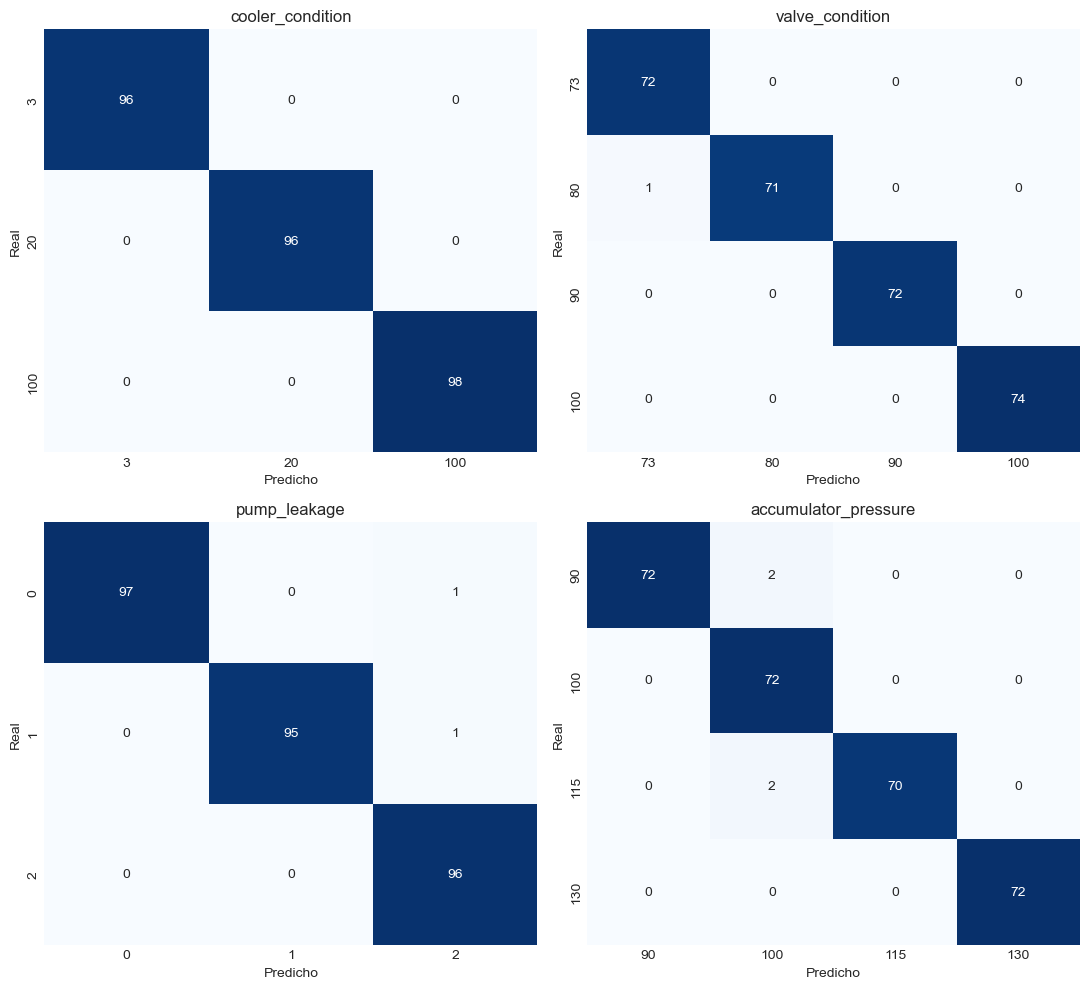

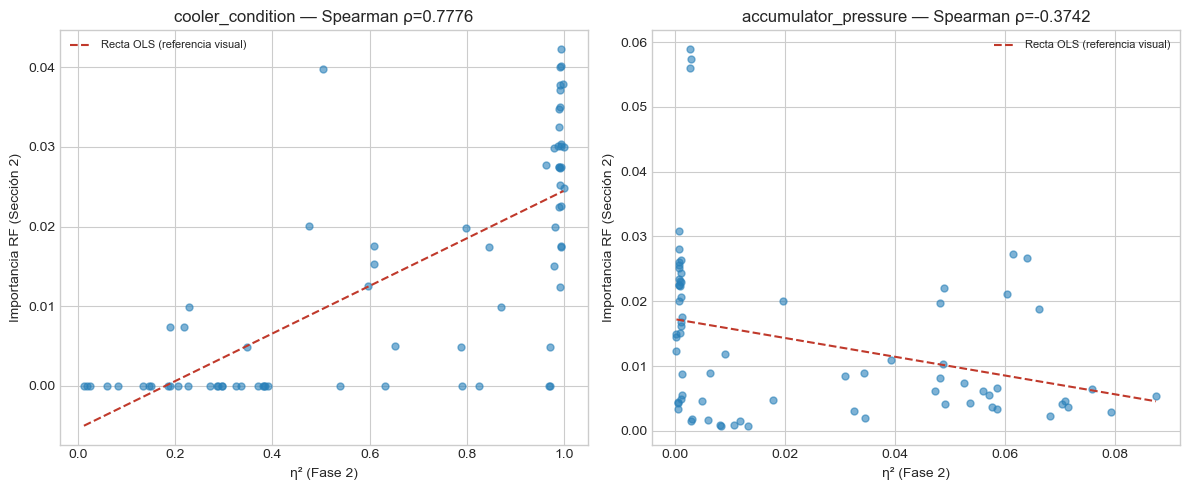

In [8]:
FIGURES_DIR = Path.cwd().parent / "reports" / "figures"  # misma carpeta que las Fases 1, 2 y 3
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── (a) Matrices de confusión de los 4 targets, en una grilla 2x2 ──
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(11, 10))
for ax, target in zip(axes_cm.flat, TARGETS):
    class_names = sorted(y_train[target].unique().tolist())
    cm = confusion_matrix(y_test[target], y_pred_by_target[target], labels=class_names)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(target)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_confusion_matrices.png", bbox_inches="tight")
plt.show()

# ── (b) Dispersión eta^2 vs. importancia RF, para cooler_condition (rho alto) y accumulator_pressure (rho negativo) ──
scatter_targets = {"cooler_condition": 0.7776, "accumulator_pressure": -0.3742}  # rho ya calculado en la Sección 2

fig_sc, axes_sc = plt.subplots(1, 2, figsize=(12, 5))
for ax, (target, rho) in zip(axes_sc, scatter_targets.items()):
    rf_full = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)  # mismos hiperparámetros que la Sección 2
    rf_full.fit(X_train, y_train[target])
    importances = pd.Series(rf_full.feature_importances_, index=X_train.columns)
    eta2_vals = eta2_df.reindex(importances.index)[target]

    ax.scatter(eta2_vals, importances, alpha=0.6, s=25, color="#2980b9")
    slope, intercept = np.polyfit(eta2_vals, importances, 1)
    x_line = np.array([eta2_vals.min(), eta2_vals.max()])
    ax.plot(x_line, slope * x_line + intercept, color="#c0392b", linestyle="--", label="Recta OLS (referencia visual)")
    ax.set_xlabel("η² (Fase 2)")
    ax.set_ylabel("Importancia RF (Sección 2)")
    ax.set_title(f"{target} — Spearman ρ={rho:.4f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_eta2_vs_importance_scatter.png", bbox_inches="tight")
plt.show()


### Interpretación

**Las matrices de confusión confirman que los pocos errores de la Sección 3 son, casi todos, entre niveles de degradación adyacentes — con una única excepción real.** `cooler_condition` no tiene ningún error (matriz perfectamente diagonal, 0/290). `valve_condition` tiene 1 error: un ciclo con `valve_condition` real=80 predicho como 73 — niveles contiguos en la escala (73<80<90<100). `accumulator_pressure` tiene 4 errores, los 4 entre niveles contiguos: 2 ciclos con real=90 predichos como 100, y 2 ciclos con real=115 predichos como 100 — en ambos casos, un solo escalón de distancia en la escala ordinal (90<100<115<130). `pump_leakage` tiene 2 errores, y aquí aparece la excepción: 1 ciclo con real=1 predicho como 2 (adyacente), pero **1 ciclo con real=0 predicho como 2** — el extremo óptimo confundido con el extremo de fuga severa, saltándose el nivel intermedio por completo. Es un solo ciclo sobre 290, compatible con ruido de un caso límite específico más que con un patrón sistemático, pero contradice la expectativa de que los pocos errores del modelo respeten la estructura ordinal del problema — vale la pena señalarlo en vez de generalizar "todos los errores son adyacentes" sin comprobarlo.

**El scatter η² vs. importancia RF hace visible, en forma de nube de puntos, exactamente lo que el Spearman ρ de la Sección 2 ya decía en un solo número.** Para `cooler_condition` (ρ=0.7776), la nube muestra una tendencia ascendente clara: la mayoría de las features con η² alto (>0.9, la gran mayoría de las 73) también tienen importancia RF relativamente alta, y la recta OLS tiene pendiente positiva marcada. Para `accumulator_pressure` (ρ=-0.3742), la nube no muestra ninguna tendencia ascendente — varias de las features con importancia RF más alta se concentran en la zona de η² bajo (cerca de 0), y la recta OLS tiene pendiente ligeramente negativa, visualizando directamente lo que el ρ negativo ya afirmaba: no hay una relación monótona creciente entre "cuánto explica una feature la media del target por sí sola" y "cuánto la usa el bosque". La recta OLS es una referencia visual de tendencia lineal, no una medida de correlación de rangos — se muestra junto al ρ ya calculado en la Sección 2, no en su lugar.

**Ambas figuras documentan visualmente hallazgos ya cuantificados en las Secciones 2 y 3 — su valor es de comunicación, no de descubrimiento.** Quedan guardadas en `reports/figures/04_confusion_matrices.png` y `reports/figures/04_eta2_vs_importance_scatter.png`.
